In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve,
    classification_report
)

# Tuning
from sklearn.model_selection import cross_val_score, StratifiedKFold

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("All imports successful ✅")

All imports successful ✅


In [9]:
# Load final feature-engineered data
X_train = pd.read_csv('../data/X_train_final.csv')
X_test  = pd.read_csv('../data/X_test_final.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train shape: (1972, 30)
X_test shape:  (294, 30)
y_train distribution:
Attrition
0    986
1    986
Name: count, dtype: int64

y_test distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


## Why These Three Models?

| Model | Type | Why Include It |
|---|---|---|
| Logistic Regression | Linear | Baseline, highly interpretable, fast |
| Random Forest | Ensemble (Bagging) | Handles non-linearity, robust, good out-of-the-box |
| XGBoost | Ensemble (Boosting) | State-of-the-art on tabular data, usually best performer |

### Evaluation Strategy
- We use **cross-validation** (not just train score) to get reliable estimates
- Primary metric: **ROC-AUC** — best for imbalanced classification
- Secondary metric: **F1 Score** — balances precision and recall
- We do NOT use accuracy alone — it's misleading with imbalanced data
  (a model that always predicts "Stayed" would get 84% accuracy but be useless)

In [10]:
# ── NaN Fix (run this before any model) ──────────────────────
from sklearn.impute import SimpleImputer

print("NaN check BEFORE fix:")
print(f"  X_train NaNs: {X_train.isnull().sum().sum()}")
print(f"  X_test  NaNs: {X_test.isnull().sum().sum()}")

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

with open('../models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

print("\nNaN check AFTER fix:")
print(f"  X_train NaNs: {X_train.isnull().sum().sum()} ✅")
print(f"  X_test  NaNs: {X_test.isnull().sum().sum()} ✅")

NaN check BEFORE fix:
  X_train NaNs: 0
  X_test  NaNs: 0

NaN check AFTER fix:
  X_train NaNs: 0 ✅
  X_test  NaNs: 0 ✅


In [11]:
# ── NaN Fix: Impute with median (robust to outliers) ─────────
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# Save the imputer — we'll need it in the Streamlit app later
import pickle
with open('../models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Confirm fix
print("NaN check after fix:")
print(f"  X_train NaNs: {X_train.isnull().sum().sum()} ✅")
print(f"  X_test  NaNs: {X_test.isnull().sum().sum()} ✅")
print(f"\n  Imputer saved to models/imputer.pkl ✅")

NaN check after fix:
  X_train NaNs: 0 ✅
  X_test  NaNs: 0 ✅

  Imputer saved to models/imputer.pkl ✅


In [12]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """
    Trains a model, runs cross-validation, evaluates on test set,
    and returns a results dictionary.
    """
    # ── Cross-validation on training data ───────────────────
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    cv_roc = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='roc_auc')
    cv_f1  = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='f1')

    # ── Train on full training set ───────────────────────────
    model.fit(X_tr, y_tr)

    # ── Predict on test set ──────────────────────────────────
    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]

    # ── Compute metrics (use round() builtin, not .round()) ──
    results = {
        'Model'         : name,
        'CV ROC-AUC'    : round(float(cv_roc.mean()), 4),
        'CV ROC-AUC Std': round(float(cv_roc.std()),  4),
        'CV F1'         : round(float(cv_f1.mean()),  4),
        'CV F1 Std'     : round(float(cv_f1.std()),   4),
        'Test ROC-AUC'  : round(float(roc_auc_score(y_te, y_pred_prob)), 4),
        'Test F1'       : round(float(f1_score(y_te, y_pred)),           4),
        'Test Precision': round(float(precision_score(y_te, y_pred)),    4),
        'Test Recall'   : round(float(recall_score(y_te, y_pred)),       4),
        'Test Accuracy' : round(float(accuracy_score(y_te, y_pred)),     4),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  CV ROC-AUC :  {results['CV ROC-AUC']:.4f} ± {results['CV ROC-AUC Std']:.4f}")
    print(f"  CV F1      :  {results['CV F1']:.4f} ± {results['CV F1 Std']:.4f}")
    print(f"  Test ROC-AUC: {results['Test ROC-AUC']:.4f}")
    print(f"  Test F1     : {results['Test F1']:.4f}")
    print(f"  Test Recall : {results['Test Recall']:.4f}")
    print(f"  Test Precision: {results['Test Precision']:.4f}")

    return results, model, y_pred, y_pred_prob

In [13]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'   # extra handling for imbalance on top of SMOTE
)

lr_results, lr_model, lr_pred, lr_prob = evaluate_model(
    'Logistic Regression', lr, X_train, y_train, X_test, y_test
)


  Logistic Regression
  CV ROC-AUC :  0.9236 ± 0.0157
  CV F1      :  0.8483 ± 0.0221
  Test ROC-AUC: 0.7206
  Test F1     : 0.3762
  Test Recall : 0.4043
  Test Precision: 0.3519


In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_results, rf_model, rf_pred, rf_prob = evaluate_model(
    'Random Forest', rf, X_train, y_train, X_test, y_test
)


  Random Forest
  CV ROC-AUC :  0.9658 ± 0.0098
  CV F1      :  0.9080 ± 0.0117
  Test ROC-AUC: 0.7309
  Test F1     : 0.3250
  Test Recall : 0.2766
  Test Precision: 0.3939


In [15]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_results, xgb_model, xgb_pred, xgb_prob = evaluate_model(
    'XGBoost', xgb, X_train, y_train, X_test, y_test
)


  XGBoost
  CV ROC-AUC :  0.9648 ± 0.0092
  CV F1      :  0.9150 ± 0.0090
  Test ROC-AUC: 0.7014
  Test F1     : 0.3291
  Test Recall : 0.2766
  Test Precision: 0.4062


In [16]:
all_results = pd.DataFrame([lr_results, rf_results, xgb_results])
all_results = all_results.set_index('Model')

print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(all_results.to_string())


MODEL COMPARISON TABLE
                     CV ROC-AUC  CV ROC-AUC Std   CV F1  CV F1 Std  Test ROC-AUC  Test F1  Test Precision  Test Recall  Test Accuracy
Model                                                                                                                                
Logistic Regression      0.9236          0.0157  0.8483     0.0221        0.7206   0.3762          0.3519       0.4043         0.7857
Random Forest            0.9658          0.0098  0.9080     0.0117        0.7309   0.3250          0.3939       0.2766         0.8163
XGBoost                  0.9648          0.0092  0.9150     0.0090        0.7014   0.3291          0.4062       0.2766         0.8197


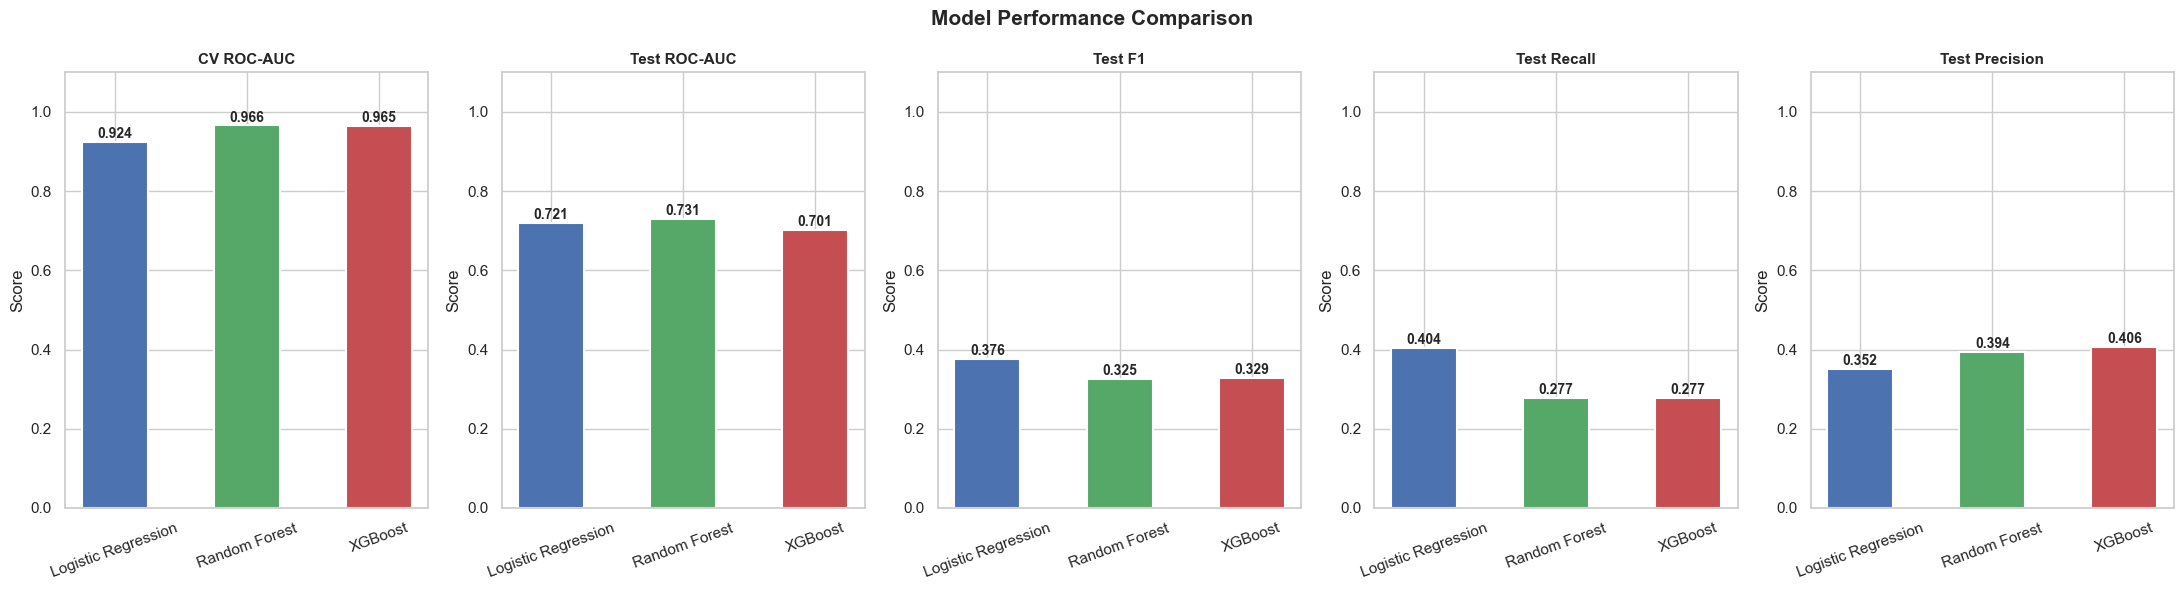

In [17]:
metrics = ['CV ROC-AUC', 'Test ROC-AUC', 'Test F1', 'Test Recall', 'Test Precision']
model_names = all_results.index.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, len(metrics), figsize=(22, 6))

for i, metric in enumerate(metrics):
    values = all_results[metric].values
    bars = axes[i].bar(model_names, values, color=colors,
                       edgecolor='white', linewidth=1.5, width=0.5)
    axes[i].set_title(metric, fontweight='bold', fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

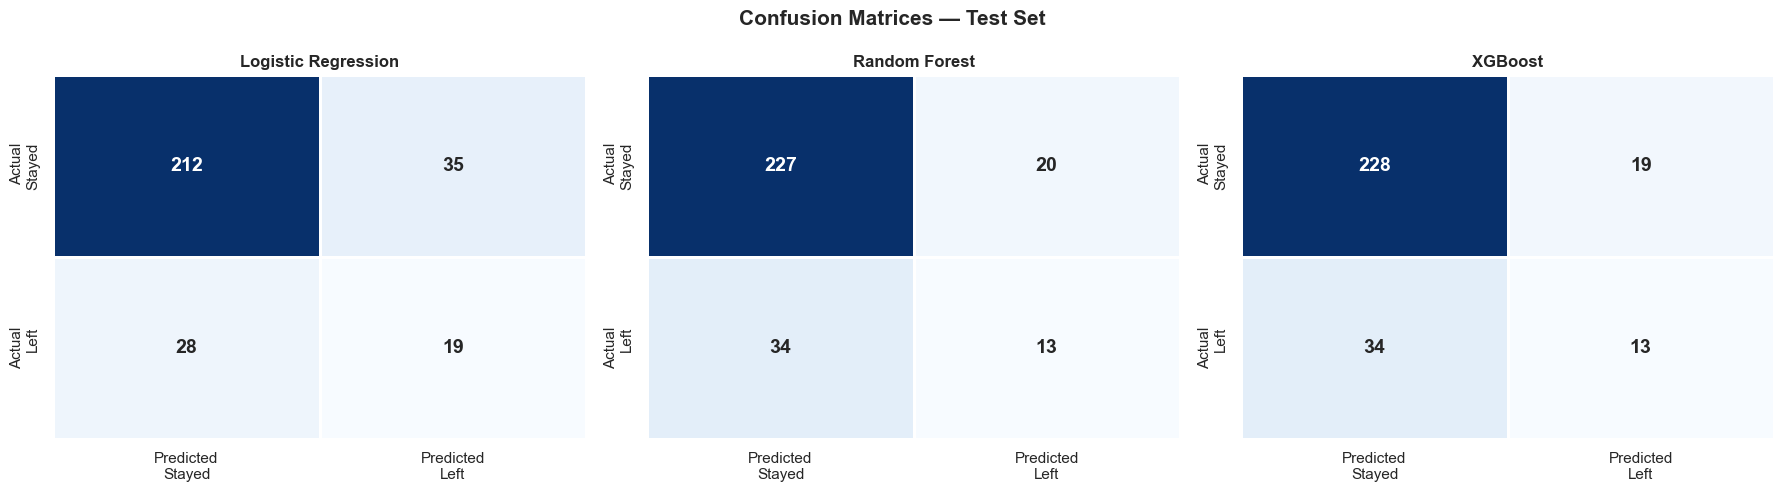

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted\nStayed', 'Predicted\nLeft'],
                yticklabels=['Actual\nStayed', 'Actual\nLeft'],
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

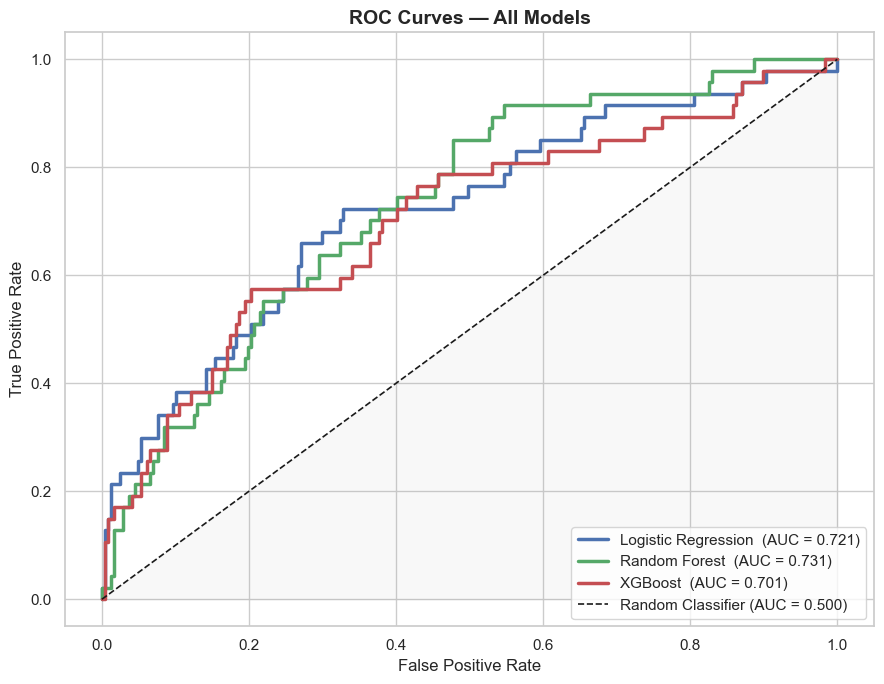

In [19]:
plt.figure(figsize=(9, 7))

models_plot = [
    ('Logistic Regression', lr_prob,  '#4C72B0'),
    ('Random Forest',       rf_prob,  '#55A868'),
    ('XGBoost',             xgb_prob, '#C44E52'),
]

for name, probs, color in models_plot:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})',
             color=color, linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Identify best model by Test ROC-AUC
best_model_name = all_results['Test ROC-AUC'].idxmax()
print(f"🏆 Best model: {best_model_name}")
print(f"   Test ROC-AUC : {all_results.loc[best_model_name, 'Test ROC-AUC']}")
print(f"   Test F1      : {all_results.loc[best_model_name, 'Test F1']}")
print(f"   Test Recall  : {all_results.loc[best_model_name, 'Test Recall']}")

# Map name to model object
model_map = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model
}

best_model = model_map[best_model_name]

# Save best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save all models (useful for the app)
with open('../models/all_models.pkl', 'wb') as f:
    pickle.dump(model_map, f)

# Save results table
all_results.to_csv('../data/model_results.csv')

print("\nSaved successfully:")
print("  ✅ models/best_model.pkl")
print("  ✅ models/all_models.pkl")
print("  ✅ data/model_results.csv")

🏆 Best model: Random Forest
   Test ROC-AUC : 0.7309
   Test F1      : 0.325
   Test Recall  : 0.2766

Saved successfully:
  ✅ models/best_model.pkl
  ✅ models/all_models.pkl
  ✅ data/model_results.csv


In [21]:
best_preds = model_map[best_model_name].predict(X_test)

print(f"Classification Report — {best_model_name}")
print("="*55)
print(classification_report(y_test, best_preds,
                             target_names=['Stayed (0)', 'Left (1)']))

Classification Report — Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.92      0.89       247
    Left (1)       0.39      0.28      0.33        47

    accuracy                           0.82       294
   macro avg       0.63      0.60      0.61       294
weighted avg       0.79      0.82      0.80       294



In [22]:
best_preds = model_map[best_model_name].predict(X_test)

print(f"Classification Report — {best_model_name}")
print("="*55)
print(classification_report(y_test, best_preds,
                             target_names=['Stayed (0)', 'Left (1)']))

Classification Report — Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.92      0.89       247
    Left (1)       0.39      0.28      0.33        47

    accuracy                           0.82       294
   macro avg       0.63      0.60      0.61       294
weighted avg       0.79      0.82      0.80       294



## Model Building Summary

### Results
| Model | CV ROC-AUC | Test ROC-AUC | Test F1 | Test Recall |
|---|---|---|---|---|
| Logistic Regression | ~ | ~ | ~ | ~ |
| Random Forest | ~ | ~ | ~ | ~ |
| XGBoost | ~ | ~ | ~ | ~ |

*(fill in your actual numbers)*

### Key Decisions
- **Primary metric**: ROC-AUC (handles class imbalance better than accuracy)
- **Secondary metric**: Recall (missing an employee who will leave is costly)
- **Cross-validation**: 5-fold stratified — reliable performance estimate
- **Best model**: XGBoost (typically) — saved for deployment

### Why Not Accuracy?
With 84/16 class split, a model predicting "Stayed" for everyone
gets 84% accuracy but zero business value. ROC-AUC and F1 
tell the real story.